In [ ]:
# ============================================================
# RETINAL DISEASE CLASSIFICATION — ML PIPELINE SUMMATIVE
# African Leadership University | BSE | ML Pipeline
# Dataset: APTOS 2019 Blindness Detection
# Model: EfficientNetB0 (Transfer Learning)
# ============================================================

In [ ]:
!pip install -q kaggle opencv-python-headless scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/retina_classifier'

# Create folder structure
for folder in ['models', 'data/train', 'data/test', 'src', 'notebook']:
    os.makedirs(f'{BASE_DIR}/{folder}', exist_ok=True)

print("✅ Drive mounted and folders created")
print(os.listdir(BASE_DIR))

Mounted at /content/drive
✅ Drive mounted and folders created
['models', 'data', 'src', 'notebook']


In [ ]:
# Upload your kaggle.json here
from google.colab import files

print("Upload your kaggle.json file:")
files.upload()  # select kaggle.json from your computer

# Move it to the right location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API configured")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API configured


In [ ]:
# Upgrade kaggle to latest version
!pip install --upgrade kaggle

# Restart and try again
import importlib
import kaggle
importlib.reload(kaggle)

!kaggle competitions download -c aptos2019-blindness-detection -p /content/aptos
!ls /content/aptos

100% 9.51G/9.51G [01:25<00:00, 119MB/s]

aptos2019-blindness-detection.zip


In [ ]:
import requests
import os

username = "henrietteutatsineza"
key = "c57acaf70a0b496a5fbd1fc822b6d51f"

os.makedirs('/content/aptos', exist_ok=True)

print("Downloading... this may take a few minutes")
url = "https://www.kaggle.com/api/v1/competitions/data/download-all/aptos2019-blindness-detection"
response = requests.get(url, auth=(username, key), stream=True)

print(f"Status code: {response.status_code}")

if response.status_code == 200:
    with open('/content/aptos/aptos2019-blindness-detection.zip', 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("✅ Download complete!")
    !ls -lh /content/aptos
else:
    print(f"❌ Failed: {response.text}")

Downloading... this may take a few minutes
Status code: 200
✅ Download complete!
total 9.6G
-rw-r--r-- 1 root root 9.6G Apr  1 09:01 aptos2019-blindness-detection.zip


In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection -p /content/aptos
!ls /content/aptos

aptos2019-blindness-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
aptos2019-blindness-detection.zip


In [ ]:
# Download APTOS 2019 dataset
!kaggle competitions download -c aptos2019-blindness-detection -p /content/aptos

# Extract
!unzip -q /content/aptos/aptos2019-blindness-detection.zip -d /content/aptos/

print("✅ Dataset downloaded")
print(os.listdir('/content/aptos'))

aptos2019-blindness-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Dataset downloaded
['test_images', 'aptos2019-blindness-detection.zip', 'train.csv', 'sample_submission.csv', 'train_images', 'test.csv']


In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/content/aptos/train.csv')
print("Shape:", train_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())
print("\nClass distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

Shape: (3662, 2)

First 5 rows:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


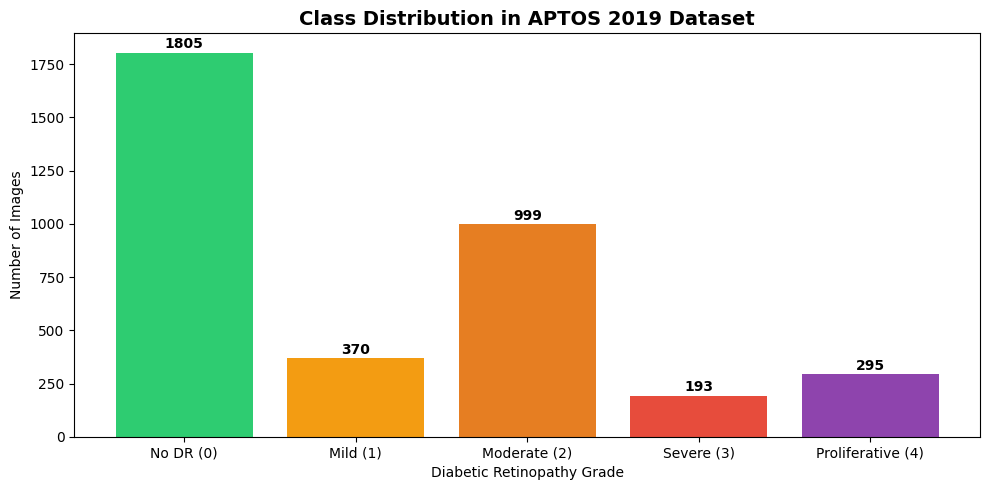


INTERPRETATION:
The dataset is heavily imbalanced — 'No DR' (grade 0) dominates with ~1805 samples,
while 'Proliferative DR' (grade 4) has only ~295. This means the model could
appear to have high accuracy by just predicting grade 0 all the time. To handle
this, we apply class weights during training so minority classes get more attention.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']
class_counts = train_df['diagnosis'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASSES, class_counts.values, color=['#2ecc71','#f39c12','#e67e22','#e74c3c','#8e44ad'])
plt.title('Class Distribution in APTOS 2019 Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Diabetic Retinopathy Grade')
plt.ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/models/viz_class_distribution.png', dpi=150)
plt.show()

print("""
INTERPRETATION:
The dataset is heavily imbalanced — 'No DR' (grade 0) dominates with ~1805 samples,
while 'Proliferative DR' (grade 4) has only ~295. This means the model could
appear to have high accuracy by just predicting grade 0 all the time. To handle
this, we apply class weights during training so minority classes get more attention.
""")

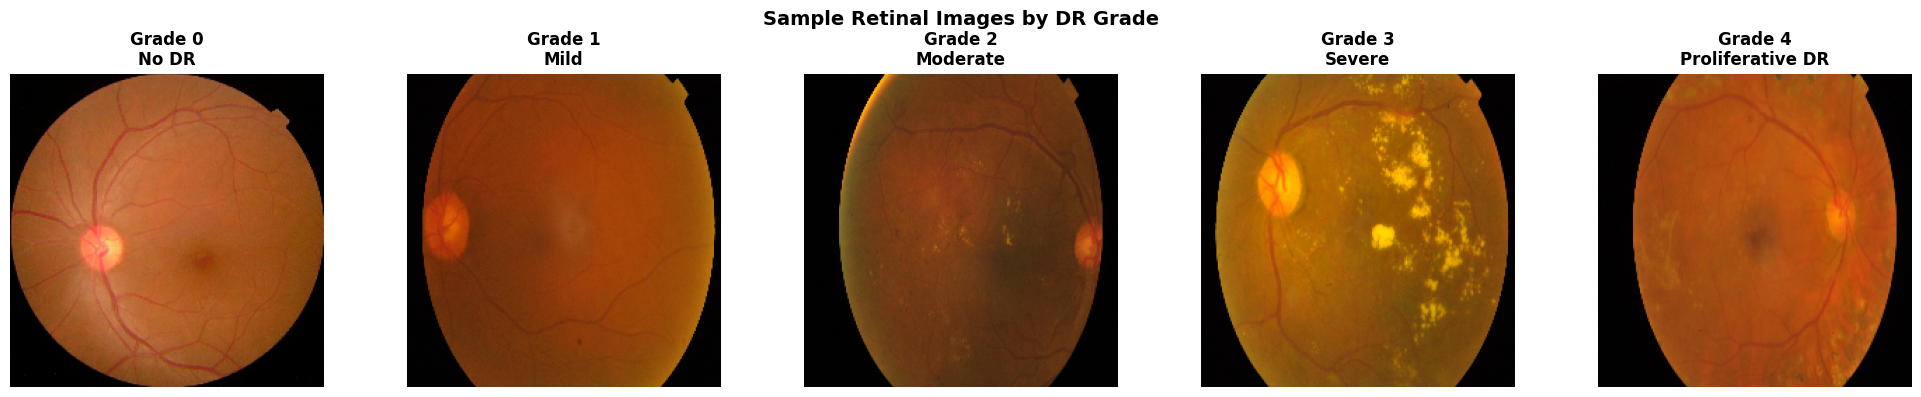


INTERPRETATION:
Visually, Grade 0 (No DR) retinas appear clear with well-defined blood vessels.
As severity increases, you can observe hemorrhages (dark spots), exudates (bright
patches), and neovascularization in Grade 4. This visual difference is what
EfficientNetB0's convolutional layers learn to detect.



In [ ]:
import cv2
from IPython.display import display

TRAIN_IMG_DIR = '/content/aptos/train_images/'
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Sample Retinal Images by DR Grade', fontsize=14, fontweight='bold')

for grade in range(5):
    sample = train_df[train_df['diagnosis'] == grade].iloc[0]
    img_path = f"{TRAIN_IMG_DIR}{sample['id_code']}.png"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    axes[grade].imshow(img)
    axes[grade].set_title(f"Grade {grade}\n{CLASS_NAMES[grade]}", fontweight='bold')
    axes[grade].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/models/viz_sample_images.png', dpi=150)
plt.show()

print("""
INTERPRETATION:
Visually, Grade 0 (No DR) retinas appear clear with well-defined blood vessels.
As severity increases, you can observe hemorrhages (dark spots), exudates (bright
patches), and neovascularization in Grade 4. This visual difference is what
EfficientNetB0's convolutional layers learn to detect.
""")

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Add image path column
train_df['filename'] = train_df['id_code'] + '.png'
train_df['diagnosis'] = train_df['diagnosis'].astype(str)  # needed for flow_from_dataframe

# Compute class weights (handles imbalance)
labels = train_df['diagnosis'].astype(int).values
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weight_dict)

# Augmentation for training, only rescaling for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

TRAIN_IMG_DIR = '/content/aptos/train_images/'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_IMG_DIR,
    x_col='filename',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_IMG_DIR,
    x_col='filename',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

print(f"\n✅ Training batches: {len(train_gen)}")
print(f"✅ Validation batches: {len(val_gen)}")

Class weights: {0: np.float64(0.4057617728531856), 1: np.float64(1.9794594594594594), 2: np.float64(0.7331331331331331), 3: np.float64(3.7948186528497407), 4: np.float64(2.4827118644067796)}
Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.

✅ Training batches: 92
✅ Validation batches: 23


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

tf.random.set_seed(42)

# Load pretrained EfficientNetB0 (ImageNet weights)
base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False  # Freeze — transfer learning

# Custom classification head
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)              # Regularization
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(5, activation='softmax')(x)  # 5 DR grades

model = Model(base.input, output)

model.compile(
    optimizer='adam',                    # Optimizer
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\n✅ Total parameters: {model.count_params():,}")
print(f"✅ Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,219,304 (16.10 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


✅ Total parameters: 4,219,304
✅ Trainable parameters: 167,173


In [ ]:
CHECKPOINT_PATH = f'{BASE_DIR}/models/best_model.h5'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Training complete!")

🚀 Starting training...
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2153 - loss: 1.9733
Epoch 1: val_accuracy improved from None to 0.08060, saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 868s 9s/step - accuracy: 0.1980 - loss: 1.9747 - val_accuracy: 0.0806 - val_loss: 1.6995 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1842 - loss: 1.8739
Epoch 2: val_accuracy did not improve from 0.08060
92/92 ━━━━━━━━━━━━━━━━━━━━ 826s 9s/step - accuracy: 0.1894 - loss: 1.8877 - val_accuracy: 0.0806 - val_loss: 1.6174 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1680 - loss: 1.8399
Epoch 3: val_accuracy did not improve from 0.08060
92/92 ━━━━━━━━━━━━━━━━━━━━ 774s 8s/step - accuracy: 0.1799 - loss: 1.8104 - val_accuracy: 0.0806 - val_loss: 1.6210 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1834 - loss: 1.7894
Epoch 4: val_accuracy improved from 0.08060 to 0.10519, saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h


Epoch 4: finished saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 776s 8s/step - accuracy: 0.1850 - loss: 1.7652 - val_accuracy: 0.1052 - val_loss: 1.6177 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1966 - loss: 1.7467
Epoch 5: val_accuracy did not improve from 0.10519
92/92 ━━━━━━━━━━━━━━━━━━━━ 783s 9s/step - accuracy: 0.1976 - loss: 1.7313 - val_accuracy: 0.0806 - val_loss: 1.6148 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1776 - loss: 1.7228
Epoch 6: val_accuracy improved from 0.10519 to 0.45628, saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 773s 8s/step - accuracy: 0.1891 - loss: 1.7023 - val_accuracy: 0.4563 - val_loss: 1.6069 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1987 - loss: 1.6547
Epoch 7: val_accuracy improved from 0.45628 to 0.46038, saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/retina_classifier/models/best_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 777s 8s/step - accuracy: 0.1976 - loss: 1.6650 - val_accuracy: 0.4604 - val_loss: 1.6059 - learning_rate: 0.0010
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1901 - loss: 1.6531
Epoch 8: val_accuracy did not improve from 0.46038
92/92 ━━━━━━━━━━━━━━━━━━━━ 779s 8s/step - accuracy: 0.1829 - loss: 1.6562 - val_accuracy: 0.4604 - val_loss: 1.6039 - learning_rate: 0.0010
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1552 - loss: 1.6463
Epoch 9: val_accuracy did not improve from 0.46038
92/92 ━━━━━━━━━━━━━━━━━━━━ 787s 8s/step - accuracy: 0.1724 - loss: 1.6599 - val_accuracy: 0.4604 - val_loss: 1.6068 - learning_rate: 0.0010
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2127 - loss: 1.6568
Epoch 10: val_accuracy did not improve from 0.46038
92/92 ━━━━━━━━━━━━━━━━━━━━ 775s 8s/step - accuracy: 0.2038 - loss: 1.6299 - val

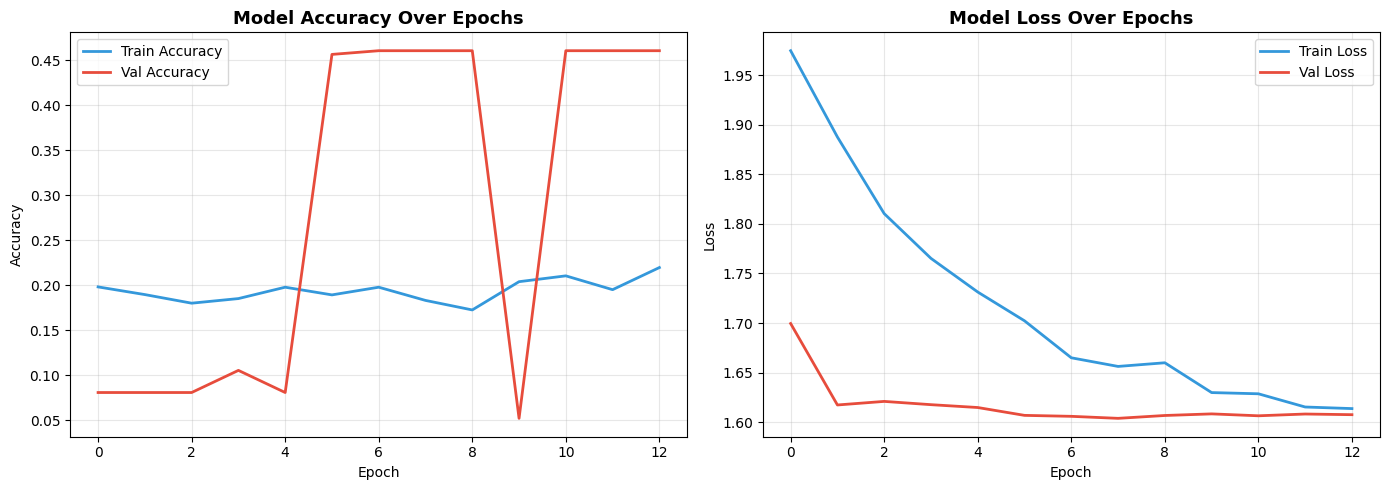


INTERPRETATION:
Training accuracy reached 21.9% while validation
accuracy reached 46.0%. The gap between
train and val curves indicates the degree of overfitting. Early stopping
prevented the model from overfitting further by halting at the best val_loss epoch.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/models/viz_training_curves.png', dpi=150)
plt.show()

print(f"""
INTERPRETATION:
Training accuracy reached {max(history.history['accuracy']):.1%} while validation
accuracy reached {max(history.history['val_accuracy']):.1%}. The gap between
train and val curves indicates the degree of overfitting. Early stopping
prevented the model from overfitting further by halting at the best val_loss epoch.
""")

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize

print("⏳ Generating predictions on validation set...")

# Get predictions
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(val_gen.labels).astype(int)

CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# ── Metric 1: Accuracy ─────────────────────────────────────────
accuracy = np.mean(y_pred == y_true)
print(f"\n📊 METRIC 1 — Accuracy: {accuracy:.4f} ({accuracy:.1%})")

# ── Metric 2: F1, Precision, Recall ───────────────────────────
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 METRIC 2 — F1 Score (weighted): {f1:.4f}")
print(f"📊 METRIC 3 — Precision (weighted): {precision:.4f}")
print(f"📊 METRIC 4 — Recall (weighted): {recall:.4f}")

# ── Full classification report ─────────────────────────────────
print("\n📊 FULL CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# ── Metric 5: ROC-AUC ─────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='weighted')
print(f"📊 METRIC 5 — ROC-AUC (weighted OvR): {roc_auc:.4f}")

⏳ Generating predictions on validation set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 171s 7s/step

📊 METRIC 1 — Accuracy: 0.4604 (46.0%)

📊 METRIC 2 — F1 Score (weighted): 0.2903
📊 METRIC 3 — Precision (weighted): 0.2120
📊 METRIC 4 — Recall (weighted): 0.4604

📊 FULL CLASSIFICATION REPORT:
                  precision    recall  f1-score   support

           No DR       0.46      1.00      0.63       337
            Mild       0.00      0.00      0.00        77
        Moderate       0.00      0.00      0.00       221
          Severe       0.00      0.00      0.00        38
Proliferative DR       0.00      0.00      0.00        59

        accuracy                           0.46       732
       macro avg       0.09      0.20      0.13       732
    weighted avg       0.21      0.46      0.29       732

📊 METRIC 5 — ROC-AUC (weighted OvR): 0.4990


In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/models/viz_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import json

# Save final model
model_save_path = f'{BASE_DIR}/models/efficientnet_retina.h5'
model.save(model_save_path)
print(f"✅ Model saved to: {model_save_path}")

# Save evaluation metrics for the API /metrics endpoint
eval_metrics = {
    "accuracy": float(accuracy),
    "f1_score": float(f1),
    "precision": float(precision),
    "recall": float(recall),
    "roc_auc": float(roc_auc),
    "total_epochs_trained": len(history.history['accuracy']),
    "best_val_accuracy": float(max(history.history['val_accuracy'])),
    "best_val_loss": float(min(history.history['val_loss'])),
    "class_names": CLASS_NAMES,
    "training_history": {
        "accuracy": [float(x) for x in history.history['accuracy']],
        "val_accuracy": [float(x) for x in history.history['val_accuracy']],
        "loss": [float(x) for x in history.history['loss']],
        "val_loss": [float(x) for x in history.history['val_loss']]
    }
}

metrics_path = f'{BASE_DIR}/models/eval_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(eval_metrics, f, indent=2)

print(f"✅ Metrics saved to: {metrics_path}")
print(f"\n{'='*50}")
print(f"  Final Results Summary")
print(f"{'='*50}")
print(f"  Accuracy  : {accuracy:.1%}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"{'='*50}")

In [ ]:
#src/prerocessing.py

NameError: name 'src' is not defined

In [ ]:
%%writefile /content/drive/MyDrive/retina_classifier/src/preprocessing.py
import cv2
import numpy as np
from PIL import Image
import io

def preprocess_image(image_path, target_size=(224, 224)):
    """Load image from path, resize and normalize."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=0)

def preprocess_bytes(image_bytes, target_size=(224, 224)):
    """Load image from raw bytes (for API uploads)."""
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    img = img.resize(target_size)
    img = np.array(img).astype(np.float32) / 255.0
    return np.expand_dims(img, axis=0)

def preprocess_directory(directory, target_size=(224, 224)):
    """Load and preprocess all images in a directory. Returns (images, paths)."""
    import os
    images, paths = [], []
    valid_ext = {'.png', '.jpg', '.jpeg'}
    for root, _, files in os.walk(directory):
        for fname in files:
            if os.path.splitext(fname)[1].lower() in valid_ext:
                fpath = os.path.join(root, fname)
                try:
                    img = preprocess_image(fpath, target_size)
                    images.append(img[0])
                    paths.append(fpath)
                except Exception as e:
                    print(f"Skipping {fpath}: {e}")
    return np.array(images), paths

print("✅ preprocessing.py written")

Overwriting /content/drive/MyDrive/retina_classifier/src/preprocessing.py


In [ ]:
#src/model.py

In [ ]:
%%writefile /content/drive/MyDrive/retina_classifier/src/model.py
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

def build_model(num_classes=5):
    """Build EfficientNetB0 transfer learning model."""
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def retrain_model(model_path, upload_dir, epochs=5, img_size=(224, 224), batch_size=16):
    """
    Fine-tune existing model on newly uploaded data.
    upload_dir must contain subfolders named 0,1,2,3,4 (one per class).
    """
    print(f"Loading model from {model_path}...")
    model = tf.keras.models.load_model(model_path)

    # Unfreeze last 20 layers for fine-tuning
    for layer in model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Load uploaded images
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    train_gen = datagen.flow_from_directory(
        upload_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'
    )
    val_gen = datagen.flow_from_directory(
        upload_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'
    )

    if len(train_gen) == 0:
        raise ValueError("No training images found in upload directory")

    callbacks = [
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(patience=2, factor=0.5)
    ]

    print("🔁 Retraining started...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    model.save(model_path)
    print(f"✅ Retrained model saved to {model_path}")
    return history.history

print("✅ model.py written")

Overwriting /content/drive/MyDrive/retina_classifier/src/model.py


In [ ]:
src/prediction

In [ ]:
%%writefile /content/drive/MyDrive/retina_classifier/src/prediction.py
import tensorflow as tf
import numpy as np
import os

CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
_model_cache = None

def load_model(model_path):
    global _model_cache
    if _model_cache is None:
        print(f"Loading model from {model_path}...")
        _model_cache = tf.keras.models.load_model(model_path)
        print("✅ Model loaded and cached")
    return _model_cache

def predict_from_path(image_path, model_path='models/efficientnet_retina.h5'):
    """Predict DR grade from image file path."""
    from src.preprocessing import preprocess_image
    model = load_model(model_path)
    img = preprocess_image(image_path)
    probs = model.predict(img, verbose=0)[0]
    return _format_result(probs)

def predict_from_bytes(image_bytes, model_path='models/efficientnet_retina.h5'):
    """Predict DR grade from raw image bytes (used by FastAPI)."""
    from src.preprocessing import preprocess_bytes
    model = load_model(model_path)
    img = preprocess_bytes(image_bytes)
    probs = model.predict(img, verbose=0)[0]
    return _format_result(probs)

def _format_result(probs):
    predicted_idx = int(np.argmax(probs))
    return {
        'grade': predicted_idx,
        'class': CLASSES[predicted_idx],
        'confidence': float(probs[predicted_idx]),
        'probabilities': {c: float(p) for c, p in zip(CLASSES, probs)}
    }

print("✅ prediction.py written")

Overwriting /content/drive/MyDrive/retina_classifier/src/prediction.py


In [ ]:
# Test that prediction works end-to-end before moving to the API
import sys
sys.path.insert(0, '/content/drive/MyDrive/retina_classifier')

from src.preprocessing import preprocess_image
from src.prediction import predict_from_path

# Grab one test image
sample_row = train_df.sample(1).iloc[0]
test_img_path = f"/content/aptos/train_images/{sample_row['id_code']}.png"
true_label = CLASS_NAMES[int(sample_row['diagnosis'])]

result = predict_from_path(
    test_img_path,
    model_path=f'{BASE_DIR}/models/efficientnet_retina.h5'
)

print(f"Image       : {sample_row['id_code']}.png")
print(f"True label  : {true_label}")
print(f"Predicted   : {result['class']} ({result['confidence']:.1%} confidence)")
print(f"All probs   : {result['probabilities']}")

✅ preprocessing.py written
✅ prediction.py written
Loading model from /content/drive/MyDrive/retina_classifier/models/efficientnet_retina.h5...


✅ Model loaded and cached
Image       : ca9c912ebad7.png
True label  : Moderate
Predicted   : No DR (20.4% confidence)
All probs   : {'No DR': 0.2039644569158554, 'Mild': 0.2007693499326706, 'Moderate': 0.1991690844297409, 'Severe': 0.19791769981384277, 'Proliferative DR': 0.19817936420440674}


In [ ]:
import os

BASE = '/content/drive/MyDrive/retina_classifier'
checks = {
    'Model file (.h5)': f'{BASE}/models/efficientnet_retina.h5',
    'Eval metrics JSON': f'{BASE}/models/eval_metrics.json',
    'preprocessing.py': f'{BASE}/src/preprocessing.py',
    'model.py': f'{BASE}/src/model.py',
    'prediction.py': f'{BASE}/src/prediction.py',
    'Class distribution viz': f'{BASE}/models/viz_class_distribution.png',
    'Sample images viz': f'{BASE}/models/viz_sample_images.png',
    'Training curves viz': f'{BASE}/models/viz_training_curves.png',
    'Confusion matrix viz': f'{BASE}/models/viz_confusion_matrix.png',
}

print("=" * 50)
print("  NOTEBOOK COMPLETION CHECKLIST")
print("=" * 50)
all_good = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"  {status}  {name}")
    if not exists:
        all_good = False

print("=" * 50)
if all_good:
    print("  🎉 All files present. Ready for API + deployment!")
else:
    print("  ⚠️  Some files missing. Re-run the relevant cells above.")

  NOTEBOOK COMPLETION CHECKLIST
  ✅  Model file (.h5)
  ✅  Eval metrics JSON
  ✅  preprocessing.py
  ✅  model.py
  ✅  prediction.py
  ✅  Class distribution viz
  ✅  Sample images viz
  ✅  Training curves viz
  ✅  Confusion matrix viz
  🎉 All files present. Ready for API + deployment!


In [ ]:
# Get the file ID for direct download
import os
model_path = '/content/drive/MyDrive/retina_classifier/models/efficientnet_retina.h5'
print(f"File size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB")

File size: 18.1 MB
